In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [3]:
data = {
    "Study_Hours" : list(range(1,9)),
    "Study_Hours_per_week" : [x*7 for x in list(range(1,9))],
    "Attendance" : list(range(60, 100, 5)),
    "Assignment_Score" : [46, 55, 58, 65, 70, 74, 81, 88],
    "Final Marks" : [42, 48, 54, 61, 67, 73, 81, 89]
}
data

{'Study_Hours': [1, 2, 3, 4, 5, 6, 7, 8],
 'Study_Hours_per_week': [7, 14, 21, 28, 35, 42, 49, 56],
 'Attendance': [60, 65, 70, 75, 80, 85, 90, 95],
 'Assignment_Score': [46, 55, 58, 65, 70, 74, 81, 88],
 'Final Marks': [42, 48, 54, 61, 67, 73, 81, 89]}

In [4]:
df = pd.DataFrame(data)
x = df[["Study_Hours", "Study_Hours_per_week", "Attendance", "Assignment_Score"]]
y = df["Final Marks"]

In [5]:
model = LinearRegression()
model.fit(x,y)
print("Intercept:", model.intercept_)

Intercept: 4.032391713747693


In [6]:
coefficient_table = pd.DataFrame({
    "Feature:" : x.columns,
    "Coeffient" : model.coef_
})
coefficient_table

,Feature:,Coeffient
0,Study_Hours,0.065827
1,Study_Hours_per_week,0.460787
2,Attendance,0.329134
3,Assignment_Score,0.298305


In [7]:
new_student = pd.DataFrame({
    'Study_Hours': [10],
    'Study_Hours_per_week' : [70],
 'Attendance': [100],
 'Assignment_Score': [100]})

In [8]:
prediction = model.predict(new_student)
prediction

array([99.68964218])

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)

In [10]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred = model.predict(x_test)

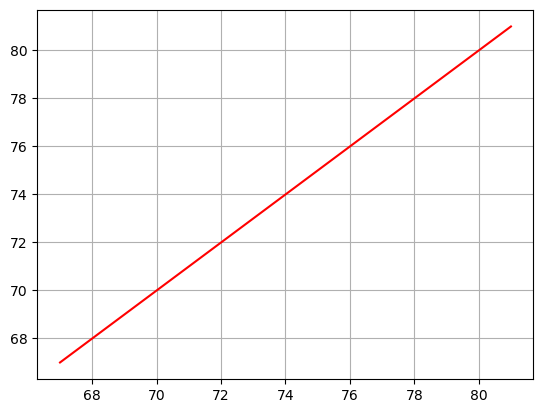

In [12]:
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red"
)
plt.grid(True)

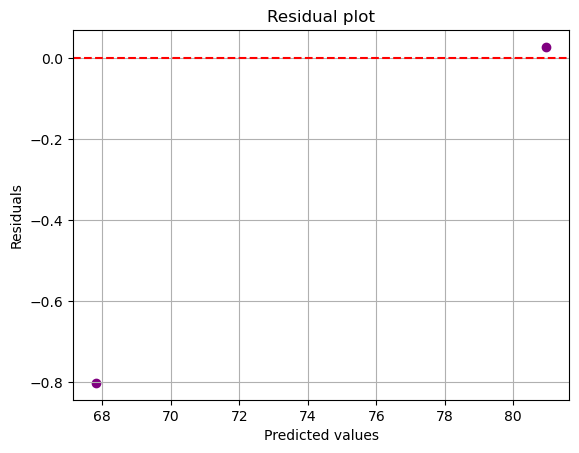

In [13]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.grid(True)
plt.show()

In [14]:
print("Actual:",y_test.values)
print("Predicted:", y_pred)

Actual: [67 81]
Predicted: [67.80188679 80.97169811]
